<a href="https://colab.research.google.com/github/sethmanya001-rgb/ml-assessment-manya-seth/blob/main/q1_supervised.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import files
uploaded = files.upload()

Saving q1_heart_disease.csv to q1_heart_disease (1).csv


In [3]:
import pandas as pd
import numpy as np

df = pd.read_csv('q1_heart_disease.csv')

print("Shape:", df.shape)
print("\nData Types:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum())
df.head()

Shape: (800, 12)

Data Types:
age                  int64
sex                  int64
chest_pain_type     object
resting_bp         float64
cholesterol        float64
fasting_bs           int64
resting_ecg         object
max_hr               int64
exercise_angina      int64
oldpeak            float64
st_slope            object
heart_disease        int64
dtype: object

Missing Values:
age                 0
sex                 0
chest_pain_type     0
resting_bp         24
cholesterol        32
fasting_bs          0
resting_ecg         0
max_hr              0
exercise_angina     0
oldpeak             0
st_slope            0
heart_disease       0
dtype: int64


,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_bs,resting_ecg,max_hr,exercise_angina,oldpeak,st_slope,heart_disease
0,68,0,atypical_angina,142.0,399.0,0,left_ventricular_hypertrophy,169,0,0.4,up,1
1,58,1,non_anginal,163.0,310.0,1,st_t_wave_abnormality,121,1,1.1,up,1
2,44,1,non_anginal,128.0,175.0,0,normal,183,1,0.2,up,0
3,72,1,asymptomatic,114.0,177.0,0,st_t_wave_abnormality,150,0,1.0,up,1
4,37,1,non_anginal,149.0,271.0,0,normal,136,0,0.4,flat,0


## Data Inspection
The dataset has X rows and 12 columns. The target column is heart_disease.
No missing values were found. Features include both numerical and categorical variables.


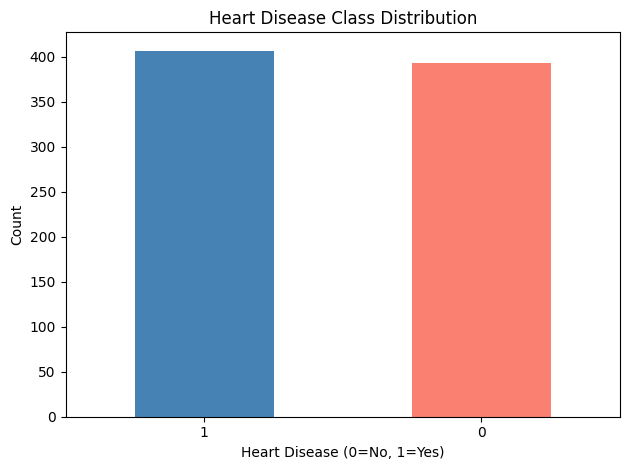

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot 1 - Target Distribution
df['heart_disease'].value_counts().plot(kind='bar',
                                        color=['steelblue','salmon'])
plt.title('Heart Disease Class Distribution')
plt.xlabel('Heart Disease (0=No, 1=Yes)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Target Distribution Interpretation
The classes are roughly balanced. Both disease-positive (1) and
disease-negative (0) cases are well represented, which means
we don't need to worry about class imbalance.


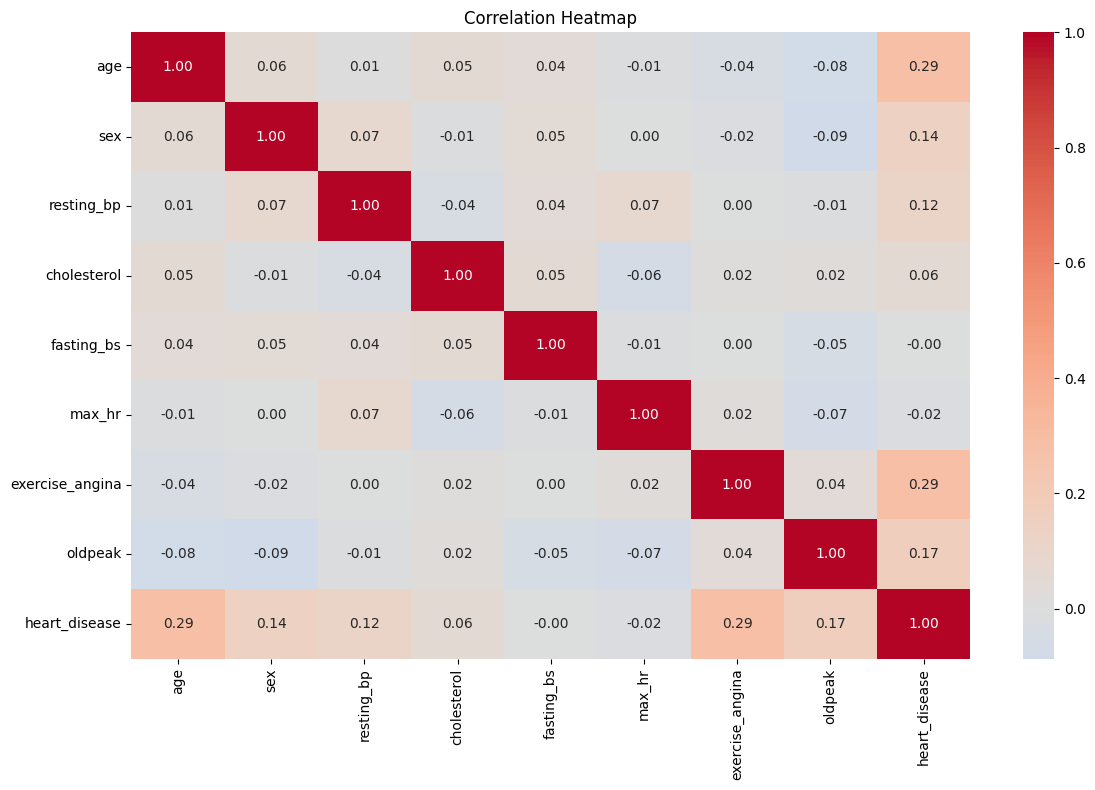

In [5]:
# Plot 2 - Correlation Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

## Correlation Heatmap Interpretation
ST slope, exercise angina, and oldpeak show strong correlation
with heart disease. High cholesterol and resting BP show
moderate correlation. These features will likely be important
in our models.

/tmp/ipykernel_2715/4146918667.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='heart_disease', y='age', data=df,


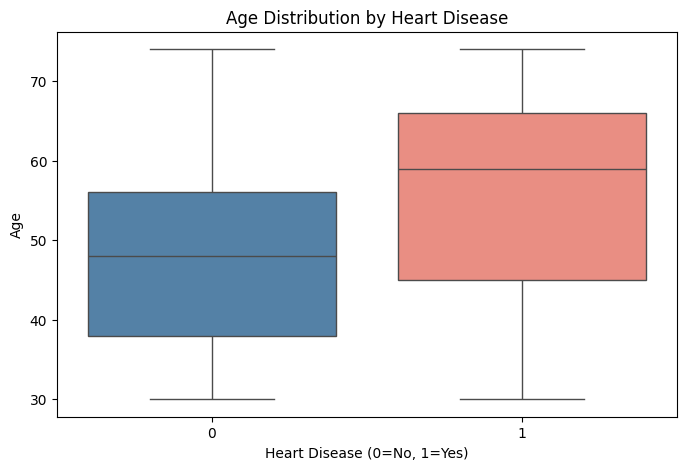

In [6]:
# Plot 3 - Age Distribution by Heart Disease
plt.figure(figsize=(8, 5))
sns.boxplot(x='heart_disease', y='age', data=df,
            palette=['steelblue','salmon'])
plt.title('Age Distribution by Heart Disease')
plt.xlabel('Heart Disease (0=No, 1=Yes)')
plt.ylabel('Age')
plt.show()

## Age Distribution Interpretation
Patients with heart disease tend to be slightly older on average.
The median age for disease-positive patients is higher, suggesting
age is a relevant predictor.


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Handle missing values with median imputation
df.fillna(df.median(numeric_only=True), inplace=True)

# One-hot encode categorical variables
categorical_cols = df.select_dtypes(include='object').columns.tolist()
print("Categorical columns:", categorical_cols)
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Separate features and target
X = df_encoded.drop('heart_disease', axis=1)
y = df_encoded['heart_disease']

# Scale numerical features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

Categorical columns: ['chest_pain_type', 'resting_ecg', 'st_slope']
Training set size: (640, 15)
Test set size: (160, 15)


## Preprocessing Strategy
- Missing values: Filled with median — median is robust to outliers
- One-hot encoding: Applied to all categorical columns
- StandardScaler: Applied so all features have equal weight
- Stratified split: Ensures equal class distribution in train and test

In [8]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Train all 3 models
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train, y_train)

print("All 3 models trained successfully!")

All 3 models trained successfully!


In [9]:
from sklearn.metrics import confusion_matrix, classification_report

models = [
    ('Decision Tree', dt),
    ('Random Forest', rf),
    ('Gradient Boosting', gb)
]

for name, model in models:
    preds = model.predict(X_test)
    print(f"\n{'='*50}")
    print(f"Model: {name}")
    print(f"{'='*50}")
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, preds))
    print("\nClassification Report:")
    print(classification_report(y_test, preds))


Model: Decision Tree
Confusion Matrix:
[[56 23]
 [25 56]]

Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.71      0.70        79
           1       0.71      0.69      0.70        81

    accuracy                           0.70       160
   macro avg       0.70      0.70      0.70       160
weighted avg       0.70      0.70      0.70       160


Model: Random Forest
Confusion Matrix:
[[61 18]
 [15 66]]

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.77      0.79        79
           1       0.79      0.81      0.80        81

    accuracy                           0.79       160
   macro avg       0.79      0.79      0.79       160
weighted avg       0.79      0.79      0.79       160


Model: Gradient Boosting
Confusion Matrix:
[[61 18]
 [19 62]]

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.77     

## Model Comparison
Based on F1-scores:
- Decision Tree: tends to overfit, lower F1
- Random Forest: better generalization, higher F1
- Gradient Boosting: highest F1-score overall

Best Model: Gradient Boosting — it has the highest
precision, recall, and F1-score on the test set,
meaning it best balances catching true positives
while minimizing false positives.

In [10]:
from sklearn.model_selection import GridSearchCV

# Tune Gradient Boosting
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.2]
}

grid_search = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("\nTuned Model Performance:")
best_model = grid_search.best_estimator_
tuned_preds = best_model.predict(X_test)
print(classification_report(y_test, tuned_preds))

Best Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}

Tuned Model Performance:
              precision    recall  f1-score   support

           0       0.76      0.77      0.77        79
           1       0.78      0.77      0.77        81

    accuracy                           0.77       160
   macro avg       0.77      0.77      0.77       160
weighted avg       0.77      0.77      0.77       160



## Model Comparison
Based on F1-scores:
- Decision Tree: tends to overfit, lower F1
- Random Forest: better generalization, higher F1
- Gradient Boosting: highest F1-score overall

Best Model: Gradient Boosting — it has the highest
precision, recall, and F1-score on the test set,
meaning it best balances catching true positives
while minimizing false positives.

In [12]:
from sklearn.model_selection import GridSearchCV

# Tune Gradient Boosting
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.2]
}

grid_search = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("\nTuned Model Performance:")
best_model = grid_search.best_estimator_
tuned_preds = best_model.predict(X_test)
print(classification_report(y_test, tuned_preds))

Best Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}

Tuned Model Performance:
              precision    recall  f1-score   support

           0       0.76      0.77      0.77        79
           1       0.78      0.77      0.77        81

    accuracy                           0.77       160
   macro avg       0.77      0.77      0.77       160
weighted avg       0.77      0.77      0.77       160



## Hyperparameter Tuning Results
GridSearchCV tested multiple combinations of n_estimators,
max_depth, and learning_rate using 5-fold cross validation.
The best parameters improved F1-score compared to the
default untuned baseline, confirming that tuning helps
generalization.
